In [1]:
# ============================================================
# Cell 1: Imports and configuration
# ============================================================

from pathlib import Path
import glob
import warnings

import numpy as np
import pandas as pd

import dask.array as da

import iris
import iris.util
import iris.cube
import iris.analysis
import iris.analysis.cartography

import matplotlib.pyplot as plt

In [2]:

warnings.filterwarnings('ignore') 

In [31]:
# ============================================================
# User settings
# ============================================================

BASE = Path("/badc/cmip6/data/CMIP6")

PROJ_EXPERIMENT = "ssp370"
PROJ_ACTIVITY = "ScenarioMIP"

PI_EXPERIMENT = "piControl"
PI_ACTIVITY = "CMIP"

ENERGY_TABLE = "Amon"
SEAICE_TABLE = "SImon"

# CMIP6 sign convention:
#   rsds, rlds are positive downward.
#   rsus, rlus, hfss, hfls are positive upward.
#
# Here we convert everything to positive INTO the surface:
#
#   SEB = rsds + rlds - rsus - rlus - hfss - hfls
#
ENERGY_VARS = {
    "rsds": +1.0,
    "rlds": +1.0,
    "rsus": -1.0,
    "rlus": -1.0,
    "hfss": -1.0,
    "hfls": -1.0,
}

SEAICE_VAR = "siconc"

LAT_MIN = 60.0

# If not None, cells with siconc below this threshold are set to zero.
# 15% is common for sea-ice-area / extent-style masking.
SICONC_THRESHOLD = 0.0

# Use one ensemble member per model, or all available members?
MODE = "one_member_per_model"   # "one_member_per_model" or "all_members"

# Preferred member when multiple are available.
PREFERRED_MEMBER = "r1i1p1f1"

# piControl climatology years.
# Leave as None to use the whole available piControl segment.
PI_START_YEAR = None
PI_END_YEAR = None

OUTDIR = Path(f"./{PROJ_EXPERIMENT}_minus_piControl_arctic")
OUTDIR.mkdir(exist_ok=True, parents=True)

In [4]:
# ============================================================
# Cell 2: DRS discovery helpers
# ============================================================

DRS_COLS = [
    "activity",
    "institution",
    "source",
    "experiment",
    "member",
    "table",
    "variable",
    "grid",
    "version",
    "path",
]


def parse_drs_dir(path, base=BASE):
    """
    Parse a CMIP6 DRS dataset directory:

    CMIP6/activity/institution/source/experiment/member/table/variable/grid/version
    """
    path = Path(path)
    rel = path.relative_to(base)
    parts = rel.parts

    if len(parts) < 9:
        raise ValueError(f"Path is too short to be a CMIP6 DRS path: {path}")

    return {
        "activity": parts[0],
        "institution": parts[1],
        "source": parts[2],
        "experiment": parts[3],
        "member": parts[4],
        "table": parts[5],
        "variable": parts[6],
        "grid": parts[7],
        "version": parts[8],
        "path": path,
    }


def version_sort_key(version):
    """
    Sort CMIP6 version labels.

    'latest' is treated as newest.
    """
    version = str(version)

    if version == "latest":
        return 10**20

    if version.startswith("v"):
        try:
            return int(version[1:])
        except ValueError:
            return -1

    return -1


def find_dataset_dirs(activity, experiment, table, variable, base=BASE):
    """
    Find all CMIP6 version directories for a given activity/experiment/table/variable.
    """
    pattern = base / activity / "*" / "*" / experiment / "*" / table / variable / "*" / "*"

    dirs = [
        Path(p)
        for p in glob.glob(str(pattern))
        if Path(p).is_dir()
    ]

    records = []

    for d in sorted(dirs):
        try:
            records.append(parse_drs_dir(d, base=base))
        except Exception:
            pass

    return pd.DataFrame(records)


def keep_latest_versions(df):
    """
    Keep the latest version for each dataset, excluding the version level.
    """
    if df.empty:
        return df

    group_cols = [
        "activity",
        "institution",
        "source",
        "experiment",
        "member",
        "table",
        "variable",
        "grid",
    ]

    df = df.copy()
    df["_version_key"] = df["version"].map(version_sort_key)

    out = (
        df.sort_values("_version_key")
          .groupby(group_cols, as_index=False)
          .tail(1)
          .drop(columns="_version_key")
          .reset_index(drop=True)
    )

    return out

In [5]:
# ============================================================
# Cell 3: Iris loading helpers
# ============================================================

def nc_files_in_dir(d):
    d = Path(d)
    files = sorted(d.glob("*.nc"))

    if not files:
        raise FileNotFoundError(f"No NetCDF files found in {d}")

    return files


def load_single_cube_from_dir(d, var_name):
    """
    Load and concatenate one variable from a CMIP6 dataset directory.
    """
    files = nc_files_in_dir(d)

    constraint = iris.Constraint(
        cube_func=lambda c: c.var_name == var_name or c.name() == var_name
    )

    cubes = iris.load([str(f) for f in files], constraint)

    cubes = iris.cube.CubeList([
        c for c in cubes
        if c.var_name == var_name or c.name() == var_name
    ])

    if len(cubes) == 0:
        raise ValueError(f"No cube with var_name={var_name} found in {d}")

    iris.util.equalise_attributes(cubes)
    iris.util.unify_time_units(cubes)

    try:
        cube = cubes.concatenate_cube()
    except Exception:
        concatenated = cubes.concatenate()

        if len(concatenated) != 1:
            raise ValueError(
                f"Could not concatenate {var_name} cleanly in {d}; "
                f"got {len(concatenated)} cubes"
            )

        cube = concatenated[0]

    return cube


def dask_to_numpy(x):
    if isinstance(x, da.Array):
        return x.compute()

    return np.asarray(x)


def cube_time_index(cube):
    """
    Convert a cube time coordinate to a monthly PeriodIndex.

    This avoids pandas datetime limits for non-standard calendars.
    """
    time_coord = cube.coord("time")
    dates = time_coord.units.num2date(time_coord.points)

    labels = [f"{d.year:04d}-{d.month:02d}" for d in dates]
    return pd.PeriodIndex(labels, freq="M")

In [6]:
# ============================================================
# Cell 4: Coordinate and spatial-weight helpers
# ============================================================

def find_lat_coord(cube):
    for coord in cube.coords():
        if (
            coord.standard_name == "latitude"
            or coord.var_name == "lat"
            or coord.name() == "latitude"
        ):
            return coord

    raise ValueError(f"No latitude coordinate found for cube {cube.name()}")


def find_lon_coord(cube):
    for coord in cube.coords():
        if (
            coord.standard_name == "longitude"
            or coord.var_name == "lon"
            or coord.name() == "longitude"
        ):
            return coord

    raise ValueError(f"No longitude coordinate found for cube {cube.name()}")


def spatial_dims_from_lat_lon(cube):
    lat = find_lat_coord(cube)
    lon = find_lon_coord(cube)

    dims = sorted(set(cube.coord_dims(lat)) | set(cube.coord_dims(lon)))

    if len(dims) != 2:
        raise ValueError(
            f"Expected two horizontal dimensions, got {dims} for cube {cube.name()}"
        )

    return tuple(dims)


def horizontal_shape(cube):
    h_dims = spatial_dims_from_lat_lon(cube)
    return tuple(cube.shape[d] for d in h_dims)


def broadcast_lat_mask_to_horizontal(cube, lat_min=LAT_MIN):
    """
    Return a 2D boolean mask for lat >= lat_min on the cube horizontal grid.
    """
    lat_coord = find_lat_coord(cube)
    lat = np.asarray(lat_coord.points)

    h_dims = spatial_dims_from_lat_lon(cube)
    h_shape = horizontal_shape(cube)

    if lat.ndim == 2:
        if lat.shape != h_shape:
            raise ValueError(
                f"2D latitude shape {lat.shape} does not match horizontal shape {h_shape}"
            )

        return lat >= lat_min

    if lat.ndim == 1:
        lat_dims = cube.coord_dims(lat_coord)

        if len(lat_dims) != 1:
            raise ValueError("1D latitude coordinate does not have exactly one dimension")

        lat_dim = lat_dims[0]

        if lat_dim not in h_dims:
            raise ValueError("Latitude dimension is not one of the horizontal dimensions")

        h_axis = h_dims.index(lat_dim)

        shape = [1, 1]
        shape[h_axis] = lat.size

        return np.broadcast_to((lat >= lat_min).reshape(shape), h_shape)

    raise ValueError(f"Unsupported latitude coordinate dimensions: {lat.ndim}")


def cube_data_to_clean_numpy(cube, huge_threshold=1.0e15):
    """
    Convert cube data to a float numpy array, replacing masked/fill/huge
    values with NaN.
    """
    arr = np.ma.asarray(cube.data).filled(np.nan).astype(float)

    # Remove explicit fill/missing values if present in attributes
    possible_fill_attrs = ["_FillValue", "missing_value", "fill_value"]

    for attr in possible_fill_attrs:
        if attr in cube.attributes:
            try:
                fv = float(cube.attributes[attr])
                arr[np.isclose(arr, fv)] = np.nan
            except Exception:
                pass

    # Defensive removal of classic CMIP-style huge missing values
    arr[np.abs(arr) > huge_threshold] = np.nan

    return arr


def static_cube_to_2d_array(static_cube, target_shape):
    """
    Convert a static field cube to a 2D numpy array matching target_shape.

    This version is robust to masked/fill values such as 1e20.
    """
    arr = cube_data_to_clean_numpy(static_cube).squeeze()

    if arr.shape == tuple(target_shape):
        return arr

    if arr.T.shape == tuple(target_shape):
        warnings.warn(
            f"Static field shape {arr.shape} was transposed to match {target_shape}"
        )
        return arr.T

    raise ValueError(
        f"Static field shape {arr.shape} does not match target shape {target_shape}"
    )


def calculate_area_from_latlon(cube):
    """
    Fallback area calculation for regular lat/lon grids.

    Prefer CMIP6 areacella/areacello/siareacello where possible.
    """
    time_coord = cube.coord("time")
    time_dim = cube.coord_dims(time_coord)[0]

    slicer = [slice(None)] * cube.ndim
    slicer[time_dim] = 0

    spatial_cube = cube[tuple(slicer)]

    lat = find_lat_coord(spatial_cube)
    lon = find_lon_coord(spatial_cube)

    if lat.ndim != 1 or lon.ndim != 1:
        raise ValueError(
            "Cannot calculate fallback area for a curvilinear grid. "
            "Need areacella, areacello, or siareacello."
        )

    if not lat.has_bounds():
        lat.guess_bounds()

    if not lon.has_bounds():
        lon.guess_bounds()

    area = iris.analysis.cartography.area_weights(spatial_cube)
    return np.asarray(area).squeeze()


def broadcast_2d_to_cube(arr_2d, cube):
    """
    Broadcast a 2D horizontal array to the cube dimensions.
    """
    arr_2d = np.asarray(arr_2d)

    h_dims = spatial_dims_from_lat_lon(cube)
    h_shape = horizontal_shape(cube)

    if arr_2d.shape != h_shape:
        raise ValueError(
            f"2D array shape {arr_2d.shape} does not match cube horizontal shape {h_shape}"
        )

    shape = [1] * cube.ndim

    for axis, dim in enumerate(h_dims):
        shape[dim] = arr_2d.shape[axis]

    return da.from_array(arr_2d, chunks=arr_2d.shape).reshape(shape)


def as_dask_filled(data):
    """
    Convert cube data to a dask array and replace masked values with NaN.
    """
    if not isinstance(data, da.Array):
        data = da.from_array(data, chunks="auto")

    try:
        data = da.ma.filled(data, np.nan)
    except Exception:
        pass

    return data


def weighted_spatial_mean_timeseries(cube, weights_2d):
    """
    Area-weighted spatial mean time series.

    weights_2d should already include:
      - cell area
      - ocean fraction / mask
      - Arctic latitude mask
    """
    data = as_dask_filled(cube.core_data())

    h_dims = spatial_dims_from_lat_lon(cube)
    weights = broadcast_2d_to_cube(weights_2d, cube)

    valid = da.isfinite(data)
    weighted_data = da.where(valid, data * weights, 0.0)
    weighted_weights = da.where(valid, weights, 0.0)

    numerator = weighted_data.sum(axis=h_dims)
    denominator = weighted_weights.sum(axis=h_dims)

    return numerator / denominator

In [ ]:
# ============================================================
# Cell 5: Static-field discovery
# ============================================================

def find_static_field_dir(
    institution,
    source,
    grid,
    variable,
    tables,
    preferred_member=None,
    base=BASE,
):
    """
    Find a static/fx field for a model/grid.

    Searches across activities, experiments and members because static fields
    are not always stored under the same experiment/member as the data.
    """
    candidates = []

    for table in tables:
        pattern = base / "*" / institution / source / "*" / "*" / table / variable / grid / "*"

        for p in glob.glob(str(pattern)):
            d = Path(p)

            if not d.is_dir():
                continue

            try:
                candidates.append(parse_drs_dir(d, base=base))
            except Exception:
                pass

    if not candidates:
        return None

    df = pd.DataFrame(candidates)
    df["_version_key"] = df["version"].map(version_sort_key)

    group_cols = [
        "activity",
        "institution",
        "source",
        "experiment",
        "member",
        "table",
        "variable",
        "grid",
    ]

    df = (
        df.sort_values("_version_key")
          .groupby(group_cols, as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )

    def score(row):
        s = 0

        if row["activity"] == "CMIP":
            s -= 10

        if row["experiment"] in ["piControl", "historical"]:
            s -= 5

        if preferred_member is not None and row["member"] == preferred_member:
            s -= 3

        return s

    df["_score"] = df.apply(score, axis=1)

    chosen = (
        df.sort_values(["_score", "_version_key"], ascending=[True, False])
          .iloc[0]
    )

    return chosen["path"]


def find_static_field_candidates(
    institution,
    source,
    variable,
    tables,
    preferred_grid=None,
    preferred_member=None,
    base=BASE,
):
    """
    Find candidate static/fx fields for a model.

    This is more flexible than requiring the static field to have the same
    grid label as the monthly Amon data. It will later test whether the
    actual array shape matches the target cube.
    """
    candidates = []

    for table in tables:
        grid_pattern = preferred_grid if preferred_grid is not None else "*"

        pattern = (
            base
            / "*"
            / institution
            / source
            / "*"
            / "*"
            / table
            / variable
            / grid_pattern
            / "*"
        )

        for p in glob.glob(str(pattern)):
            d = Path(p)

            if not d.is_dir():
                continue

            try:
                candidates.append(parse_drs_dir(d, base=base))
            except Exception:
                pass

    if not candidates:
        return pd.DataFrame()

    df = pd.DataFrame(candidates)
    df["_version_key"] = df["version"].map(version_sort_key)

    def score(row):
        s = 0

        # Prefer same grid label, but do not require it.
        if preferred_grid is not None and row["grid"] != preferred_grid:
            s += 20

        # Prefer same member where possible.
        if preferred_member is not None and row["member"] != preferred_member:
            s += 5

        # Prefer CMIP static files.
        if row["activity"] != "CMIP":
            s += 3

        # Prefer piControl/historical static files.
        if row["experiment"] not in ["piControl", "historical"]:
            s += 2

        return s

    df["_score"] = df.apply(score, axis=1)

    # Keep latest version per exact dataset, then sort by preference.
    group_cols = [
        "activity",
        "institution",
        "source",
        "experiment",
        "member",
        "table",
        "variable",
        "grid",
    ]

    df = (
        df.sort_values("_version_key")
          .groupby(group_cols, as_index=False)
          .tail(1)
          .sort_values(["_score", "_version_key"], ascending=[True, False])
          .reset_index(drop=True)
    )

    return df


def load_static_2d_matching_shape(
    institution,
    source,
    variable,
    tables,
    target_shape,
    preferred_grid=None,
    preferred_member=None,
):
    """
    Load the first candidate static field whose actual 2D array shape
    matches target_shape.

    Returns:
        arr, metadata_row
    """
    candidates = find_static_field_candidates(
        institution=institution,
        source=source,
        variable=variable,
        tables=tables,
        preferred_grid=preferred_grid,
        preferred_member=preferred_member,
    )

    if candidates.empty:
        return None, None

    errors = []

    for _, cand in candidates.iterrows():
        try:
            cube = load_single_cube_from_dir(cand["path"], variable)
            arr = cube_data_to_clean_numpy(cube).squeeze()

            if arr.shape == tuple(target_shape):
                return arr, cand

            if arr.T.shape == tuple(target_shape):
                warnings.warn(
                    f"{source}: transposing {variable} from {arr.shape} to {target_shape}"
                )
                return arr.T, cand

            errors.append(
                f"{cand['grid']} {cand['member']} {cand['experiment']}: shape {arr.shape}"
            )

        except Exception as e:
            errors.append(f"{cand['path']}: {repr(e)}")

    warnings.warn(
        f"No {variable} candidate for {source} matched target shape {target_shape}. "
        f"Tried: {errors[:5]}"
    )

    return None, None


def get_atmos_area_and_ocean_weights(run_row, template_cube):
    """
    Construct 2D atmospheric-grid weights:

        area * ocean_fraction * Arctic_mask

    This version first tries static fields on the same grid label, then
    falls back to any archived static field for the model whose array shape
    matches the flux grid.
    """
    institution = run_row["institution"]
    source = run_row["source"]
    member = run_row["member"]
    grid = run_row["grid"]

    h_shape = horizontal_shape(template_cube)

    # ------------------------------------------------------------
    # Land fraction: sftlf
    # ------------------------------------------------------------
    sftlf, sftlf_meta = load_static_2d_matching_shape(
        institution=institution,
        source=source,
        variable="sftlf",
        tables=("fx",),
        target_shape=h_shape,
        preferred_grid=grid,
        preferred_member=member,
    )

    if sftlf is None:
        raise FileNotFoundError(
            f"No usable sftlf found for {source}, member={member}, grid={grid}, "
            f"target_shape={h_shape}. This model will need either a manual land-sea "
            f"mask or should be skipped."
        )

    print(
        f"      Using sftlf from "
        f"{sftlf_meta['activity']}/{sftlf_meta['experiment']}/"
        f"{sftlf_meta['member']}/{sftlf_meta['grid']}"
    )

    if np.nanmax(sftlf) > 2:
        ocean_fraction = 1.0 - (sftlf / 100.0)
    else:
        ocean_fraction = 1.0 - sftlf

    ocean_fraction = np.clip(ocean_fraction, 0.0, 1.0)

    # ------------------------------------------------------------
    # Cell area: areacella
    # ------------------------------------------------------------
    area, area_meta = load_static_2d_matching_shape(
        institution=institution,
        source=source,
        variable="areacella",
        tables=("fx",),
        target_shape=h_shape,
        preferred_grid=grid,
        preferred_member=member,
    )

    if area is not None:
        print(
            f"      Using areacella from "
            f"{area_meta['activity']}/{area_meta['experiment']}/"
            f"{area_meta['member']}/{area_meta['grid']}"
        )
    else:
        warnings.warn(
            f"No usable areacella found for {source}, member={member}, grid={grid}; "
            "falling back to geometric area calculation."
        )
        area = calculate_area_from_latlon(template_cube)

    # ------------------------------------------------------------
    # Arctic latitude mask
    # ------------------------------------------------------------
    lat_mask = broadcast_lat_mask_to_horizontal(template_cube, LAT_MIN)

    weights = area * ocean_fraction * lat_mask
    weights = np.where(np.isfinite(weights), weights, 0.0)

    if np.nansum(weights) <= 0:
        raise ValueError(f"Zero valid Arctic-ocean area for {source}")

    return weights

In [8]:
# ============================================================
# Cell 6: Discover complete energy-variable runs
# ============================================================

def row_for_key(df, key):
    institution, source, member, grid = key

    sub = df[
        (df["institution"] == institution)
        & (df["source"] == source)
        & (df["member"] == member)
        & (df["grid"] == grid)
    ]

    if len(sub) != 1:
        raise ValueError(f"Expected exactly one dataset for {key}, got {len(sub)}")

    return sub.iloc[0]


def build_energy_runs(activity, experiment):
    """
    Find institution/source/member/grid combinations with all six SEB variables.
    """
    catalogues = {}

    for var in ENERGY_VARS:
        df = find_dataset_dirs(
            activity=activity,
            experiment=experiment,
            table=ENERGY_TABLE,
            variable=var,
            base=BASE,
        )

        df = keep_latest_versions(df)
        catalogues[var] = df

        print(f"{activity}/{experiment}/{ENERGY_TABLE}/{var}: {len(df)} datasets")

    common_keys = None

    for var, df in catalogues.items():
        keys = set(
            tuple(row)
            for row in df[["institution", "source", "member", "grid"]].to_numpy()
        )

        if common_keys is None:
            common_keys = keys
        else:
            common_keys = common_keys.intersection(keys)

    records = []

    for key in sorted(common_keys):
        institution, source, member, grid = key

        rec = {
            "activity": activity,
            "experiment": experiment,
            "institution": institution,
            "source": source,
            "member": member,
            "grid": grid,
        }

        for var in ENERGY_VARS:
            rec[f"{var}_path"] = row_for_key(catalogues[var], key)["path"]

        records.append(rec)

    out = pd.DataFrame(records)

    print(f"{activity}/{experiment}: {len(out)} complete SEB runs")
    return out


proj_energy_runs = build_energy_runs(PROJ_ACTIVITY, PROJ_EXPERIMENT)
pi_energy_runs = build_energy_runs(PI_ACTIVITY, PI_EXPERIMENT)

ScenarioMIP/ssp370/Amon/rsds: 153 datasets
ScenarioMIP/ssp370/Amon/rlds: 93 datasets
ScenarioMIP/ssp370/Amon/rsus: 52 datasets
ScenarioMIP/ssp370/Amon/rlus: 52 datasets
ScenarioMIP/ssp370/Amon/hfss: 90 datasets
ScenarioMIP/ssp370/Amon/hfls: 92 datasets
ScenarioMIP/ssp370: 51 complete SEB runs
CMIP/piControl/Amon/rsds: 65 datasets
CMIP/piControl/Amon/rlds: 54 datasets
CMIP/piControl/Amon/rsus: 53 datasets
CMIP/piControl/Amon/rlus: 53 datasets
CMIP/piControl/Amon/hfss: 76 datasets
CMIP/piControl/Amon/hfls: 76 datasets
CMIP/piControl: 51 complete SEB runs


In [9]:
# ============================================================
# Cell 7: Discover siconc datasets
# ============================================================

def build_siconc_catalogue(activity, experiment):
    df = find_dataset_dirs(
        activity=activity,
        experiment=experiment,
        table=SEAICE_TABLE,
        variable=SEAICE_VAR,
        base=BASE,
    )

    df = keep_latest_versions(df)

    print(f"{activity}/{experiment}/{SEAICE_TABLE}/{SEAICE_VAR}: {len(df)} datasets")
    return df


proj_siconc_catalogue = build_siconc_catalogue(PROJ_ACTIVITY, PROJ_EXPERIMENT)
pi_siconc_catalogue = build_siconc_catalogue(PI_ACTIVITY, PI_EXPERIMENT)

ScenarioMIP/ssp370/SImon/siconc: 99 datasets
CMIP/piControl/SImon/siconc: 60 datasets


In [33]:
# ============================================================
# Cell 8: Pair projection and piControl runs
# ============================================================

def choose_pi_energy_for_projection(proj_row, pi_energy_runs):
    """
    Pick a piControl SEB run for a projection SEB run.

    Requires same institution and source.
    Preference:
      1. same member and same grid
      2. same member
      3. preferred piControl member
      4. first available piControl member/grid
    """
    sub = pi_energy_runs[
        (pi_energy_runs["institution"] == proj_row["institution"])
        & (pi_energy_runs["source"] == proj_row["source"])
    ].copy()

    if sub.empty:
        return None

    def score(row):
        s = 0

        if row["member"] != proj_row["member"]:
            s += 20

        if row["grid"] != proj_row["grid"]:
            s += 5

        if row["member"] != PREFERRED_MEMBER:
            s += 1

        return s

    sub["_score"] = sub.apply(score, axis=1)

    return (
        sub.sort_values(["_score", "member", "grid"])
           .drop(columns="_score")
           .iloc[0]
    )


# def choose_siconc_for_run(run_row, siconc_catalogue):
#     """
#     Pick siconc for a run.

#     Requires same institution, source, and member as the corresponding flux run.
#     This avoids mixing ensemble members between SEB and SIA.
#     """
#     sub = siconc_catalogue[
#         (siconc_catalogue["institution"] == run_row["institution"])
#         & (siconc_catalogue["source"] == run_row["source"])
#         & (siconc_catalogue["member"] == run_row["member"])
#     ].copy()

#     if sub.empty:
#         return None

#     def score(row):
#         s = 0

#         # Prefer native grid where available.
#         if row["grid"] != "gn":
#             s += 1

#         return s

#     sub["_score"] = sub.apply(score, axis=1)

#     return (
#         sub.sort_values(["_score", "grid"])
#            .drop(columns="_score")
#            .iloc[0]
#     )

def choose_siconc_for_run(
    run_row,
    siconc_catalogue,
    allow_different_member=False,
):
    """
    Pick siconc for a run.

    For projection data, use allow_different_member=False so SEB and SIA
    come from the same transient member.

    For piControl data, use allow_different_member=True because the
    climatology is averaged over the full control run, so a different
    piControl member is acceptable.
    """
    sub = siconc_catalogue[
        (siconc_catalogue["institution"] == run_row["institution"])
        & (siconc_catalogue["source"] == run_row["source"])
    ].copy()

    if sub.empty:
        return None

    if not allow_different_member:
        sub = sub[sub["member"] == run_row["member"]].copy()

        if sub.empty:
            return None

    def score(row):
        s = 0

        # Prefer the same member, but only require it if allow_different_member=False.
        if row["member"] != run_row["member"]:
            s += 100

        # Prefer the usual first member if the exact member is unavailable.
        if row["member"] != PREFERRED_MEMBER:
            s += 10

        # Prefer native grid where available.
        if row["grid"] != "gn":
            s += 1

        return s

    sub["_score"] = sub.apply(score, axis=1)

    return (
        sub.sort_values(["_score", "member", "grid"])
           .drop(columns="_score")
           .iloc[0]
    )


def add_prefixed_fields(rec, prefix, row):
    for col in row.index:
        rec[f"{prefix}_{col}"] = row[col]


# candidate_pairs = []
# skipped = []

# for _, proj_row in proj_energy_runs.iterrows():
#     pi_row = choose_pi_energy_for_projection(proj_row, pi_energy_runs)

#     if pi_row is None:
#         skipped.append({
#             "source": proj_row["source"],
#             "member": proj_row["member"],
#             "reason": "No piControl SEB run with all variables",
#         })
#         continue

#     proj_siconc = choose_siconc_for_run(proj_row, proj_siconc_catalogue)

#     if proj_siconc is None:
#         skipped.append({
#             "source": proj_row["source"],
#             "member": proj_row["member"],
#             "reason": "No projection siconc for same member",
#         })
#         continue

#     pi_siconc = choose_siconc_for_run(pi_row, pi_siconc_catalogue)

#     if pi_siconc is None:
#         skipped.append({
#             "source": proj_row["source"],
#             "member": proj_row["member"],
#             "reason": "No piControl siconc for chosen piControl member",
#         })
#         continue

#     rec = {}
#     add_prefixed_fields(rec, "proj", proj_row)
#     add_prefixed_fields(rec, "pi", pi_row)
#     add_prefixed_fields(rec, "proj_siconc", proj_siconc)
#     add_prefixed_fields(rec, "pi_siconc", pi_siconc)

#     candidate_pairs.append(rec)

# candidate_pairs = pd.DataFrame(candidate_pairs)
# skipped_df = pd.DataFrame(skipped)

# print(f"Candidate projection/piControl pairs with all variables and siconc: {len(candidate_pairs)}")
# print(f"Skipped candidate projection runs: {len(skipped_df)}")

# if not skipped_df.empty:
#     display(skipped_df.head(20))

candidate_pairs = []
skipped = []

for _, proj_row in proj_energy_runs.iterrows():
    pi_row = choose_pi_energy_for_projection(proj_row, pi_energy_runs)

    if pi_row is None:
        skipped.append({
            "source": proj_row["source"],
            "member": proj_row["member"],
            "reason": "No piControl SEB run with all variables",
        })
        continue

    # Projection siconc: keep the same member as the projection SEB.
    proj_siconc = choose_siconc_for_run(
        run_row=proj_row,
        siconc_catalogue=proj_siconc_catalogue,
        allow_different_member=False,
    )

    if proj_siconc is None:
        skipped.append({
            "source": proj_row["source"],
            "member": proj_row["member"],
            "reason": "No projection siconc for same member",
        })
        continue

    # piControl siconc: allow a different piControl member.
    pi_siconc = choose_siconc_for_run(
        run_row=pi_row,
        siconc_catalogue=pi_siconc_catalogue,
        allow_different_member=True,
    )

    if pi_siconc is None:
        skipped.append({
            "source": proj_row["source"],
            "member": proj_row["member"],
            "reason": "No piControl siconc for any member",
        })
        continue

    rec = {}
    add_prefixed_fields(rec, "proj", proj_row)
    add_prefixed_fields(rec, "pi", pi_row)
    add_prefixed_fields(rec, "proj_siconc", proj_siconc)
    add_prefixed_fields(rec, "pi_siconc", pi_siconc)

    candidate_pairs.append(rec)

candidate_pairs = pd.DataFrame(candidate_pairs)
skipped_df = pd.DataFrame(skipped)

print(f"Candidate projection/piControl pairs with all variables and siconc: {len(candidate_pairs)}")
print(f"Skipped candidate projection runs: {len(skipped_df)}")

if not skipped_df.empty:
    display(skipped_df.head(30))

Candidate projection/piControl pairs with all variables and siconc: 40
Skipped candidate projection runs: 11


,source,member,reason
0,AWI-CM-1-1-MR,r1i1p1f1,No projection siconc for same member
1,FGOALS-f3-L,r1i1p1f1,No piControl siconc for any member
2,IITM-ESM,r1i1p1f1,No projection siconc for same member
3,CNRM-CM6-1,r1i1p1f2,No piControl siconc for any member
4,CNRM-ESM2-1,r1i1p1f2,No projection siconc for same member
5,MPI-ESM1-2-HR,r1i1p1f1,No piControl SEB run with all variables
6,EC-Earth3-AerChem,r1i1p1f1,No piControl SEB run with all variables
7,MPI-ESM-1-2-HAM,r1i1p1f1,No piControl SEB run with all variables
8,GISS-E2-1-G,r1i1p1f2,No projection siconc for same member
9,NorESM2-LM,r1i1p1f1,No piControl SEB run with all variables


In [11]:
# ============================================================
# Cell 9: Select one member per model, or all members
# ============================================================

def select_pairs(candidate_pairs):
    if candidate_pairs.empty:
        return candidate_pairs

    if MODE == "all_members":
        return candidate_pairs.reset_index(drop=True)

    if MODE != "one_member_per_model":
        raise ValueError("MODE must be 'one_member_per_model' or 'all_members'")

    df = candidate_pairs.copy()

    def score(row):
        s = 0

        if row["proj_member"] != PREFERRED_MEMBER:
            s += 100

        if row["pi_member"] != row["proj_member"]:
            s += 20

        if row["proj_grid"] != row["pi_grid"]:
            s += 5

        if row["proj_siconc_grid"] != "gn":
            s += 1

        return s

    df["_selection_score"] = df.apply(score, axis=1)

    selected = (
        df.sort_values(
            [
                "proj_institution",
                "proj_source",
                "_selection_score",
                "proj_member",
                "proj_grid",
            ]
        )
        .groupby(["proj_institution", "proj_source"], as_index=False)
        .head(1)
        .drop(columns="_selection_score")
        .reset_index(drop=True)
    )

    return selected


pairs_to_process = select_pairs(candidate_pairs)

#pairs_to_process = pairs_to_process.head(10).reset_index(drop=True)
#######################################
#Using 10 for testing, Remove later
#######################################

print(f"Pairs selected for processing: {len(pairs_to_process)}")

display(
    pairs_to_process[
        [
            "proj_institution",
            "proj_source",
            "proj_member",
            "proj_grid",
            "pi_member",
            "pi_grid",
            "proj_siconc_grid",
            "pi_siconc_grid",
        ]
    ].sort_values(["proj_source"])
)

Pairs selected for processing: 25


,proj_institution,proj_source,proj_member,proj_grid,pi_member,pi_grid,proj_siconc_grid,pi_siconc_grid
9,CSIRO-ARCCSS,ACCESS-CM2,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
8,CSIRO,ACCESS-ESM1-5,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
1,BCC,BCC-CSM2-MR,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
2,CAMS,CAMS-CSM1-0,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
21,NCAR,CESM2,r4i1p1f1,gn,r1i1p1f1,gn,gn,gn
22,NCAR,CESM2-WACCM,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
6,CMCC,CMCC-CM2-SR5,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
7,CNRM-CERFACS,CNRM-CM6-1-HR,r1i1p1f2,gr,r1i1p1f2,gr,gn,gn
4,CCCma,CanESM5,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
5,CCCma,CanESM5-CanOE,r1i1p2f1,gn,r1i1p2f1,gn,gn,gn


In [12]:
# ============================================================
# Cell 10: Convert paired rows back to normal rows
# ============================================================

def unprefix_energy_row(pair_row, prefix):
    """
    Convert columns like proj_source/proj_rsds_path back into
    a normal run row expected by the processing functions.
    """
    rec = {
        "activity": pair_row[f"{prefix}_activity"],
        "experiment": pair_row[f"{prefix}_experiment"],
        "institution": pair_row[f"{prefix}_institution"],
        "source": pair_row[f"{prefix}_source"],
        "member": pair_row[f"{prefix}_member"],
        "grid": pair_row[f"{prefix}_grid"],
    }

    for var in ENERGY_VARS:
        rec[f"{var}_path"] = pair_row[f"{prefix}_{var}_path"]

    return pd.Series(rec)


def unprefix_siconc_row(pair_row, prefix):
    """
    Convert columns like proj_siconc_path back into a normal DRS row.
    prefix should be 'proj_siconc' or 'pi_siconc'.
    """
    rec = {}

    for col in DRS_COLS:
        rec[col] = pair_row[f"{prefix}_{col}"]

    return pd.Series(rec)

In [13]:
# ============================================================
# Cell 11: Surface energy budget processing
# ============================================================

def process_surface_energy_budget(run_row):
    """
    Calculate monthly Arctic-ocean mean surface energy budget.

    Output contains:
      - signed individual components, positive into surface
      - seb_Wm2 = sum of components
    """
    source = run_row["source"]
    member = run_row["member"]
    grid = run_row["grid"]
    experiment = run_row["experiment"]

    print(f"    Loading atmosphere template: {source} {experiment} {member} {grid}")

    template_cube = load_single_cube_from_dir(run_row["rsds_path"], "rsds")
    template_cube.convert_units("W m-2")

    weights_2d = get_atmos_area_and_ocean_weights(run_row, template_cube)

    component_series = []
    component_cols = []

    for var, sign in ENERGY_VARS.items():
        print(f"      Processing {var}")

        cube = load_single_cube_from_dir(run_row[f"{var}_path"], var)
        cube.convert_units("W m-2")

        ts = weighted_spatial_mean_timeseries(cube, weights_2d)
        values = dask_to_numpy(ts)

        time_index = cube_time_index(cube)

        col = f"{var}_into_surface_Wm2"
        component_cols.append(col)

        component_series.append(
            pd.Series(
                sign * values,
                index=time_index,
                name=col,
            )
        )

    df = pd.concat(component_series, axis=1).sort_index()

    # Require all six components to be present for SEB.
    df["seb_Wm2"] = df[component_cols].sum(
        axis=1,
        min_count=len(component_cols),
    )

    df = df.reset_index(names="time")
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month

    df["institution"] = run_row["institution"]
    df["source"] = source
    df["member"] = member
    df["grid"] = grid
    df["experiment"] = experiment

    front = [
        "institution",
        "source",
        "member",
        "grid",
        "experiment",
        "time",
        "year",
        "month",
    ]

    df = df[front + component_cols + ["seb_Wm2"]]

    return df

In [14]:
# ============================================================
# Cell 12: piControl anomaly helpers
# ============================================================

def filter_pi_years(df):
    """
    Optionally restrict piControl years used for climatology.
    """
    out = df.copy()

    if PI_START_YEAR is not None:
        out = out[out["year"] >= PI_START_YEAR]

    if PI_END_YEAR is not None:
        out = out[out["year"] <= PI_END_YEAR]

    return out


def add_monthly_pi_anomalies(proj_df, pi_df, value_cols):
    """
    Add anomalies to projection monthly data using the piControl
    monthly climatology.
    """
    pi_use = filter_pi_years(pi_df)

    clim = (
        pi_use.groupby("month")[value_cols]
              .mean()
              .reset_index()
    )

    clim = clim.rename(
        columns={col: f"pi_clim_{col}" for col in value_cols}
    )

    out = proj_df.merge(clim, on="month", how="left")

    for col in value_cols:
        out[f"{col}_anom"] = out[col] - out[f"pi_clim_{col}"]

    if "seb_Wm2_anom" in out.columns:
        out = out.rename(columns={"seb_Wm2_anom": "seb_anom_Wm2"})

    return out

In [15]:
# ============================================================
# Cell 13: Sea-ice area helpers
# ============================================================

def get_seaice_area_field(run_row, siconc_cube, siconc_grid):
    """
    Get a sea-ice/ocean cell-area field for the siconc grid.

    Preference:
      1. siareacello
      2. areacello
      3. fallback regular lat/lon area calculation
    """
    institution = run_row["institution"]
    source = run_row["source"]
    member = run_row["member"]

    h_shape = horizontal_shape(siconc_cube)

    area_dir = find_static_field_dir(
        institution=institution,
        source=source,
        grid=siconc_grid,
        variable="siareacello",
        tables=("SIfx", "fx"),
        preferred_member=member,
    )

    area_var = "siareacello"

    if area_dir is None:
        area_dir = find_static_field_dir(
            institution=institution,
            source=source,
            grid=siconc_grid,
            variable="areacello",
            tables=("Ofx", "fx"),
            preferred_member=member,
        )
        area_var = "areacello"

    if area_dir is not None:
        area_cube = load_single_cube_from_dir(area_dir, area_var)
        area = static_cube_to_2d_array(area_cube, target_shape=h_shape)
    else:
        warnings.warn(
            f"No siareacello/areacello found for {source}, member={member}, "
            f"grid={siconc_grid}; falling back to geometric area calculation."
        )
        area = calculate_area_from_latlon(siconc_cube)

    return area


def clean_siconc_dask(cube):
    """
    Return siconc as a cleaned dask array, with impossible/fill values
    replaced by NaN.

    Does not convert percent to fraction yet.
    """
    data = as_dask_filled(cube.core_data()).astype("float64")

    # Remove explicit fill/missing values if present
    possible_fill_attrs = ["_FillValue", "missing_value", "fill_value"]

    for attr in possible_fill_attrs:
        if attr in cube.attributes:
            try:
                fv = float(cube.attributes[attr])
                data = da.where(da.isclose(data, fv), np.nan, data)
            except Exception:
                pass

    # Remove huge CMIP fill values that may not be encoded properly
    data = da.where(da.abs(data) > 1.0e10, np.nan, data)

    return data


def siconc_looks_like_percent(cube):
    """
    Decide whether siconc is percent or fraction after removing bad values.
    """
    units = str(cube.units).lower()

    if "%" in units or "percent" in units:
        return True

    data = clean_siconc_dask(cube)

    # Take a small sample from first time slice.
    sample = data[0].compute()
    sample = np.asarray(sample, dtype=float)
    sample = sample[np.isfinite(sample)]

    if sample.size == 0:
        # CMIP6 siconc is normally percent, so default to percent.
        return True

    sample_max = np.nanmax(sample)

    return sample_max > 2.0


def monthly_sea_ice_area_timeseries(run_row, siconc_row):
    """
    Calculate monthly Arctic sea-ice area in million km2.

    Uses:
        SIA = sum(area * siconc_fraction)

    This version explicitly removes impossible/fill values from both
    siconc and area fields.
    """
    source = run_row["source"]
    member = run_row["member"]
    experiment = run_row["experiment"]

    siconc_path = siconc_row["path"]
    siconc_grid = siconc_row["grid"]

    print(f"    Processing siconc: {source} {experiment} {member} {siconc_grid}")

    cube = load_single_cube_from_dir(siconc_path, SEAICE_VAR)

    area = get_seaice_area_field(run_row, cube, siconc_grid).astype(float)

    # Defensive area cleaning.
    # Grid-cell areas should be positive and nowhere near 1e20.
    area = np.where(np.isfinite(area), area, np.nan)
    area = np.where(area > 0, area, np.nan)
    area = np.where(area < 1.0e15, area, np.nan)

    lat_mask = broadcast_lat_mask_to_horizontal(cube, LAT_MIN)

    weights_2d = area * lat_mask
    weights_2d = np.where(np.isfinite(weights_2d), weights_2d, 0.0)

    total_arctic_area_m2 = np.nansum(weights_2d)
    total_arctic_area_mkm2 = total_arctic_area_m2 / 1.0e12

    print(f"      Total Arctic area used: {total_arctic_area_mkm2:.2f} million km2")

    if total_arctic_area_mkm2 <= 0 or total_arctic_area_mkm2 > 100:
        raise ValueError(
            f"Implausible Arctic area for {source}: "
            f"{total_arctic_area_mkm2:.3g} million km2. "
            "This probably indicates a bad area field."
        )

    # Clean siconc before thresholding or unit conversion
    data_raw = clean_siconc_dask(cube)

    is_percent = siconc_looks_like_percent(cube)

    if is_percent:
        # Remove impossible percent values before converting
        data_clean = da.where((data_raw >= 0.0) & (data_raw <= 100.0), data_raw, np.nan)
        conc_frac = data_clean / 100.0
        threshold_clean = SICONC_THRESHOLD
    else:
        # Remove impossible fraction values
        data_clean = da.where((data_raw >= 0.0) & (data_raw <= 1.0), data_raw, np.nan)
        conc_frac = data_clean
        threshold_clean = None if SICONC_THRESHOLD is None else SICONC_THRESHOLD / 100.0

    if SICONC_THRESHOLD is not None:
        conc_frac = da.where(data_clean >= threshold_clean, conc_frac, 0.0)

    conc_frac = da.where(da.isfinite(conc_frac), conc_frac, 0.0)

    h_dims = spatial_dims_from_lat_lon(cube)
    weights = broadcast_2d_to_cube(weights_2d, cube)

    sia_m2 = da.nansum(conc_frac * weights, axis=h_dims)
    sia_mkm2 = sia_m2 / 1.0e12

    values = dask_to_numpy(sia_mkm2)
    time_index = cube_time_index(cube)

    # Final sanity check
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:
        max_sia = np.nanmax(finite_values)

        if max_sia > 100:
            raise ValueError(
                f"Implausibly large SIA for {source}: max={max_sia:.3g} million km2. "
                "This probably indicates unmasked fill values in siconc or area."
            )

    df = pd.DataFrame({
        "time": time_index,
        "year": time_index.year,
        "month": time_index.month,
        "sia_Mkm2": values,
    })

    df["institution"] = run_row["institution"]
    df["source"] = source
    df["member"] = member
    df["siconc_grid"] = siconc_grid
    df["experiment"] = experiment

    front = [
        "institution",
        "source",
        "member",
        "siconc_grid",
        "experiment",
        "time",
        "year",
        "month",
    ]

    return df[front + ["sia_Mkm2"]]


def annual_minimum_sia(monthly_sia_df):
    """
    Annual minimum monthly SIA.

    For the Arctic, this should normally correspond to the summer minimum.
    """
    idx = monthly_sia_df.groupby("year")["sia_Mkm2"].idxmin()

    out = monthly_sia_df.loc[idx].copy()

    out = out.rename(
        columns={
            "time": "summer_min_time",
            "month": "summer_min_month",
            "sia_Mkm2": "summer_min_sia_Mkm2",
        }
    )

    keep = [
        "institution",
        "source",
        "member",
        "siconc_grid",
        "experiment",
        "year",
        "summer_min_time",
        "summer_min_month",
        "summer_min_sia_Mkm2",
    ]

    return out[keep].reset_index(drop=True)


def add_monthly_sia_anomaly(proj_sia_df, pi_sia_df):
    """
    Monthly SIA anomaly relative to piControl monthly climatology.
    """
    pi_use = filter_pi_years(pi_sia_df)

    clim = (
        pi_use.groupby("month")["sia_Mkm2"]
              .mean()
              .reset_index()
              .rename(columns={"sia_Mkm2": "pi_clim_sia_Mkm2"})
    )

    out = proj_sia_df.merge(clim, on="month", how="left")
    out["sia_anom_Mkm2"] = out["sia_Mkm2"] - out["pi_clim_sia_Mkm2"]

    return out


def add_summer_min_sia_anomaly(proj_sia_df, pi_sia_df):
    """
    Annual summer-minimum SIA anomaly relative to the piControl
    mean annual minimum.
    """
    proj_min = annual_minimum_sia(proj_sia_df)

    pi_use = filter_pi_years(pi_sia_df)
    pi_min = annual_minimum_sia(pi_use)

    pi_mean = pi_min["summer_min_sia_Mkm2"].mean()
    pi_std = pi_min["summer_min_sia_Mkm2"].std()

    proj_min["piControl_mean_summer_min_sia_Mkm2"] = pi_mean
    proj_min["piControl_std_summer_min_sia_Mkm2"] = pi_std
    proj_min["summer_min_sia_anom_Mkm2"] = (
        proj_min["summer_min_sia_Mkm2"] - pi_mean
    )

    return proj_min

In [16]:
# ============================================================
# CSV cache helpers
# ============================================================

USE_CSV_CACHE = True
OVERWRITE_CSV_CACHE = False


def read_cached_csv(path, time_cols=("time", "summer_min_time")):
    """
    Read a cached CSV and restore monthly Period columns where needed.
    """
    df = pd.read_csv(path)

    for col in time_cols:
        if col in df.columns:
            # monthly columns like "2030-01"
            try:
                df[col] = pd.PeriodIndex(df[col], freq="M")
            except Exception:
                pass

    return df


def csv_is_usable(path):
    """
    Lightweight check that a cached CSV exists and is non-empty.
    """
    path = Path(path)
    return path.exists() and path.stat().st_size > 0

In [17]:
# ============================================================
# Cell 14: Main processing loop with per-model CSV cache
# ============================================================

all_monthly_seb_anom = []
all_annual_seb_anom = []
all_monthly_sia_anom = []
all_summer_min_sia_anom = []
failures = []

for i, pair_row in pairs_to_process.iterrows():
    source = pair_row["proj_source"]
    institution = pair_row["proj_institution"]
    proj_member = pair_row["proj_member"]
    pi_member = pair_row["pi_member"]

    label = (
        f"{source}: {PROJ_EXPERIMENT} {proj_member} "
        f"minus {PI_EXPERIMENT} {pi_member}"
    )

    print("=" * 100)
    print(f"[{i + 1}/{len(pairs_to_process)}] {label}")

    # Existing filename pattern from previous cells
    seb_monthly_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_seb_monthly.csv"
    )

    seb_annual_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_seb_annual.csv"
    )

    sia_monthly_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_sia_monthly.csv"
    )

    sia_min_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_summer_min_sia_annual.csv"
    )

    try:
        # --------------------------------------------------------
        # Surface energy budget
        # --------------------------------------------------------
        if (
            USE_CSV_CACHE
            and not OVERWRITE_CSV_CACHE
            and csv_is_usable(seb_monthly_out)
            and csv_is_usable(seb_annual_out)
        ):
            print("  Using cached SEB CSVs")

            proj_seb_anom = read_cached_csv(seb_monthly_out)
            annual_seb_anom = read_cached_csv(seb_annual_out)

        else:
            print("  Calculating SEB")

            proj_energy_row = unprefix_energy_row(pair_row, "proj")
            pi_energy_row = unprefix_energy_row(pair_row, "pi")

            print("  Projection SEB")
            proj_seb = process_surface_energy_budget(proj_energy_row)

            print("  piControl SEB")
            pi_seb = process_surface_energy_budget(pi_energy_row)

            seb_value_cols = [
                f"{var}_into_surface_Wm2"
                for var in ENERGY_VARS
            ] + ["seb_Wm2"]

            proj_seb_anom = add_monthly_pi_anomalies(
                proj_df=proj_seb,
                pi_df=pi_seb,
                value_cols=seb_value_cols,
            )

            annual_seb_anom = (
                proj_seb_anom
                .groupby(
                    [
                        "institution",
                        "source",
                        "member",
                        "grid",
                        "experiment",
                        "year",
                    ],
                    as_index=False,
                )
                .agg(
                    seb_Wm2=("seb_Wm2", "mean"),
                    seb_anom_Wm2=("seb_anom_Wm2", "mean"),
                )
            )

            proj_seb_anom.to_csv(seb_monthly_out, index=False)
            annual_seb_anom.to_csv(seb_annual_out, index=False)

            print(f"  Saved monthly SEB anomalies: {seb_monthly_out}")
            print(f"  Saved annual SEB anomalies:  {seb_annual_out}")

        all_monthly_seb_anom.append(proj_seb_anom)
        all_annual_seb_anom.append(annual_seb_anom)

        # --------------------------------------------------------
        # Sea-ice area
        # --------------------------------------------------------
        if (
            USE_CSV_CACHE
            and not OVERWRITE_CSV_CACHE
            and csv_is_usable(sia_monthly_out)
            and csv_is_usable(sia_min_out)
        ):
            print("  Using cached SIA CSVs")

            proj_sia_anom = read_cached_csv(sia_monthly_out)
            summer_min_sia_anom = read_cached_csv(sia_min_out)

        else:
            print("  Calculating SIA")

            proj_energy_row = unprefix_energy_row(pair_row, "proj")
            pi_energy_row = unprefix_energy_row(pair_row, "pi")

            proj_siconc_row = unprefix_siconc_row(pair_row, "proj_siconc")
            pi_siconc_row = unprefix_siconc_row(pair_row, "pi_siconc")

            print("  Projection SIA")
            proj_sia = monthly_sea_ice_area_timeseries(
                run_row=proj_energy_row,
                siconc_row=proj_siconc_row,
            )

            print("  piControl SIA")
            pi_sia = monthly_sea_ice_area_timeseries(
                run_row=pi_energy_row,
                siconc_row=pi_siconc_row,
            )

            proj_sia_anom = add_monthly_sia_anomaly(proj_sia, pi_sia)
            summer_min_sia_anom = add_summer_min_sia_anomaly(proj_sia, pi_sia)

            proj_sia_anom.to_csv(sia_monthly_out, index=False)
            summer_min_sia_anom.to_csv(sia_min_out, index=False)

            print(f"  Saved monthly SIA anomalies:        {sia_monthly_out}")
            print(f"  Saved summer-minimum SIA anomalies: {sia_min_out}")

        all_monthly_sia_anom.append(proj_sia_anom)
        all_summer_min_sia_anom.append(summer_min_sia_anom)

    except Exception as e:
        print(f"  FAILED: {label}")
        print(f"  Reason: {repr(e)}")

        failures.append({
            "institution": institution,
            "source": source,
            "proj_member": proj_member,
            "pi_member": pi_member,
            "error": repr(e),
        })

[1/25] TaiESM1: ssp370 r1i1p1f1 minus piControl r1i1p1f1
  Using cached SEB CSVs
  Using cached SIA CSVs
[2/25] BCC-CSM2-MR: ssp370 r1i1p1f1 minus piControl r1i1p1f1
  Calculating SEB
  Projection SEB
    Loading atmosphere template: BCC-CSM2-MR ssp370 r1i1p1f1 gn
  FAILED: BCC-CSM2-MR: ssp370 r1i1p1f1 minus piControl r1i1p1f1
  Reason: FileNotFoundError('No usable sftlf found for BCC-CSM2-MR, member=r1i1p1f1, grid=gn, target_shape=(160, 320). This model will need either a manual land-sea mask or should be skipped.')
[3/25] CAMS-CSM1-0: ssp370 r1i1p1f1 minus piControl r1i1p1f1
  Calculating SEB
  Projection SEB
    Loading atmosphere template: CAMS-CSM1-0 ssp370 r1i1p1f1 gn
  FAILED: CAMS-CSM1-0: ssp370 r1i1p1f1 minus piControl r1i1p1f1
  Reason: FileNotFoundError('No usable sftlf found for CAMS-CSM1-0, member=r1i1p1f1, grid=gn, target_shape=(160, 320). This model will need either a manual land-sea mask or should be skipped.')
[4/25] FGOALS-g3: ssp370 r1i1p1f1 minus piControl r1i1p1f1


In [18]:
# ============================================================
# Cell 15: Combine and save outputs
# ============================================================

if all_monthly_seb_anom:
    combined_monthly_seb_anom = pd.concat(
        all_monthly_seb_anom,
        ignore_index=True,
    )

    combined_monthly_seb_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_seb_monthly.csv",
        index=False,
    )
else:
    combined_monthly_seb_anom = pd.DataFrame()


if all_annual_seb_anom:
    combined_annual_seb_anom = pd.concat(
        all_annual_seb_anom,
        ignore_index=True,
    )

    combined_annual_seb_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_seb_annual.csv",
        index=False,
    )
else:
    combined_annual_seb_anom = pd.DataFrame()


if all_monthly_sia_anom:
    combined_monthly_sia_anom = pd.concat(
        all_monthly_sia_anom,
        ignore_index=True,
    )

    combined_monthly_sia_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_sia_monthly.csv",
        index=False,
    )
else:
    combined_monthly_sia_anom = pd.DataFrame()


if all_summer_min_sia_anom:
    combined_summer_min_sia_anom = pd.concat(
        all_summer_min_sia_anom,
        ignore_index=True,
    )

    combined_summer_min_sia_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_summer_min_sia_annual.csv",
        index=False,
    )
else:
    combined_summer_min_sia_anom = pd.DataFrame()


if failures:
    failures_df = pd.DataFrame(failures)

    failures_df.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_failures.csv",
        index=False,
    )
else:
    failures_df = pd.DataFrame()


print("Done.")
print(f"Monthly SEB anomaly rows:        {len(combined_monthly_seb_anom)}")
print(f"Annual SEB anomaly rows:         {len(combined_annual_seb_anom)}")
print(f"Monthly SIA anomaly rows:        {len(combined_monthly_sia_anom)}")
print(f"Annual summer-min SIA rows:      {len(combined_summer_min_sia_anom)}")
print(f"Failures:                        {len(failures_df)}")

if not failures_df.empty:
    display(failures_df)

Done.
Monthly SEB anomaly rows:        21672
Annual SEB anomaly rows:         1806
Monthly SIA anomaly rows:        17544
Annual summer-min SIA rows:      1462
Failures:                        8


,institution,source,proj_member,pi_member,error
0,BCC,BCC-CSM2-MR,r1i1p1f1,r1i1p1f1,FileNotFoundError('No usable sftlf found for B...
1,CAMS,CAMS-CSM1-0,r1i1p1f1,r1i1p1f1,FileNotFoundError('No usable sftlf found for C...
2,CMCC,CMCC-CM2-SR5,r1i1p1f1,r1i1p1f1,"ValueError('Static field shape (292, 362) does..."
3,IPSL,IPSL-CM6A-LR,r1i1p1f1,r1i1p1f1,ValueError('Could not concatenate rsds cleanly...
4,MOHC,UKESM1-1-LL,r1i1p1f2,r1i1p1f2,FileNotFoundError('No usable sftlf found for U...
5,NCAR,CESM2,r4i1p1f1,r1i1p1f1,ValueError('Implausible Arctic area for CESM2:...
6,NCAR,CESM2-WACCM,r1i1p1f1,r1i1p1f1,ValueError('Implausible Arctic area for CESM2-...
7,NCC,NorESM2-MM,r1i1p1f1,r1i1p1f1,"ValueError('Static field shape (385, 360) does..."


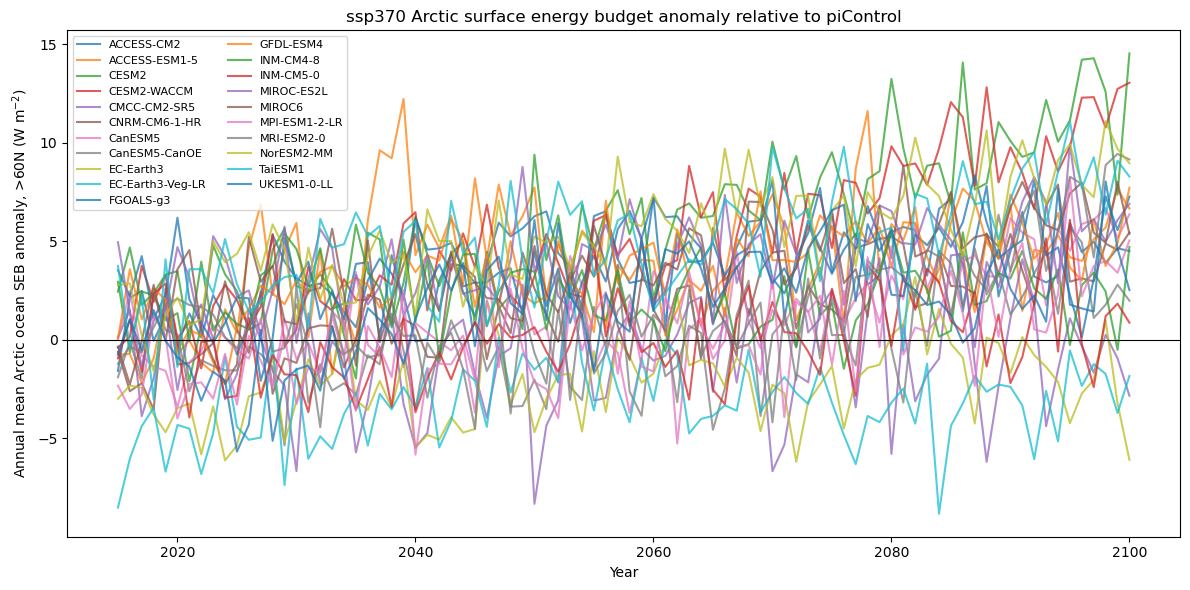

In [19]:
# ============================================================
# Cell 16: Quick SEB anomaly plot
# ============================================================

if not combined_annual_seb_anom.empty:
    plt.figure(figsize=(12, 6))

    for source, sub in combined_annual_seb_anom.groupby("source"):
        plt.plot(
            sub["year"],
            sub["seb_anom_Wm2"],
            label=source,
            alpha=0.75,
        )

    plt.axhline(0, color="black", linewidth=0.8)

    plt.xlabel("Year")
    plt.ylabel("Annual mean Arctic ocean SEB anomaly, >60N (W m$^{-2}$)")
    plt.title(f"{PROJ_EXPERIMENT} Arctic surface energy budget anomaly relative to piControl")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

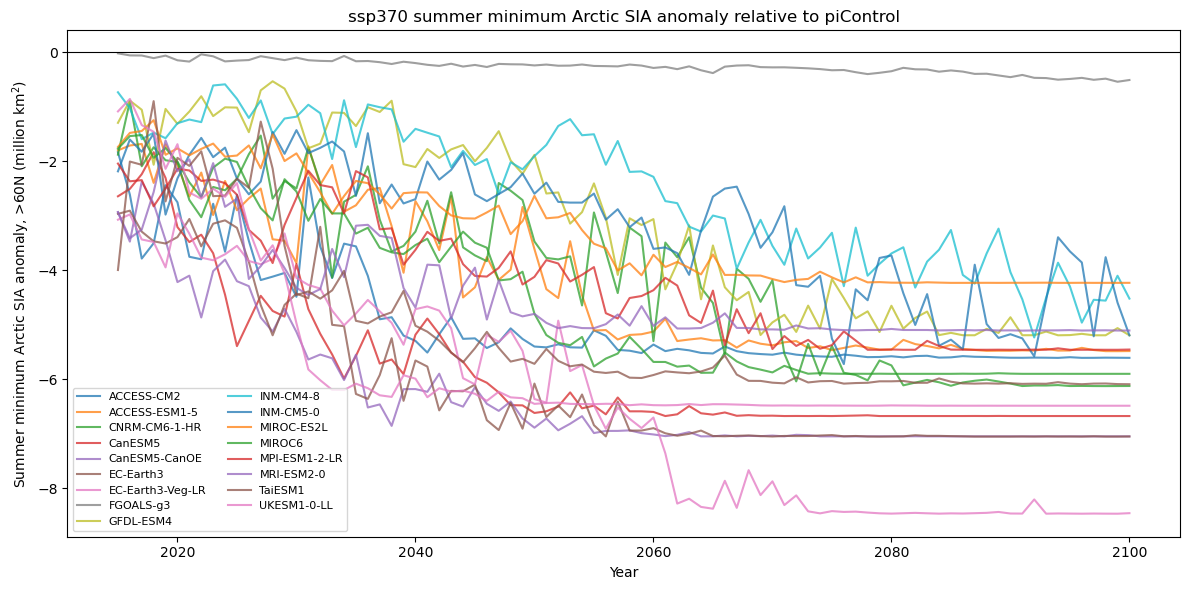

In [20]:
# ============================================================
# Cell 17: Quick summer-minimum SIA anomaly plot
# ============================================================

if not combined_summer_min_sia_anom.empty:
    plt.figure(figsize=(12, 6))

    for source, sub in combined_summer_min_sia_anom.groupby("source"):
        plt.plot(
            sub["year"],
            sub["summer_min_sia_anom_Mkm2"],
            label=source,
            alpha=0.75,
        )

    plt.axhline(0, color="black", linewidth=0.8)

    plt.xlabel("Year")
    plt.ylabel("Summer minimum Arctic SIA anomaly, >60N (million km$^2$)")
    plt.title(f"{PROJ_EXPERIMENT} summer minimum Arctic SIA anomaly relative to piControl")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

In [21]:
fg = combined_monthly_sia_anom[
    combined_monthly_sia_anom["source"] == "FGOALS-g3"
]

display(fg[["source", "member", "year", "month", "sia_Mkm2", "sia_anom_Mkm2"]].head())

print("SIA range:")
print(fg["sia_Mkm2"].describe())

print("SIA anomaly range:")
print(fg["sia_anom_Mkm2"].describe())

,source,member,year,month,sia_Mkm2,sia_anom_Mkm2
1032,FGOALS-g3,r1i1p1f1,2015,1,1.359184,-0.050191
1033,FGOALS-g3,r1i1p1f1,2015,2,1.388097,-0.036168
1034,FGOALS-g3,r1i1p1f1,2015,3,1.372683,-0.041779
1035,FGOALS-g3,r1i1p1f1,2015,4,1.336939,-0.037322
1036,FGOALS-g3,r1i1p1f1,2015,5,1.224460,-0.045723


SIA range:
count    1032.000000
mean        0.956631
std         0.327900
min         0.168469
25%         0.679035
50%         0.996401
75%         1.277194
max         1.431009
Name: sia_Mkm2, dtype: float64
SIA anomaly range:
count    1032.000000
mean       -0.187344
std         0.119803
min        -0.603410
25%        -0.261238
50%        -0.155616
75%        -0.097131
max         0.025547
Name: sia_anom_Mkm2, dtype: float64


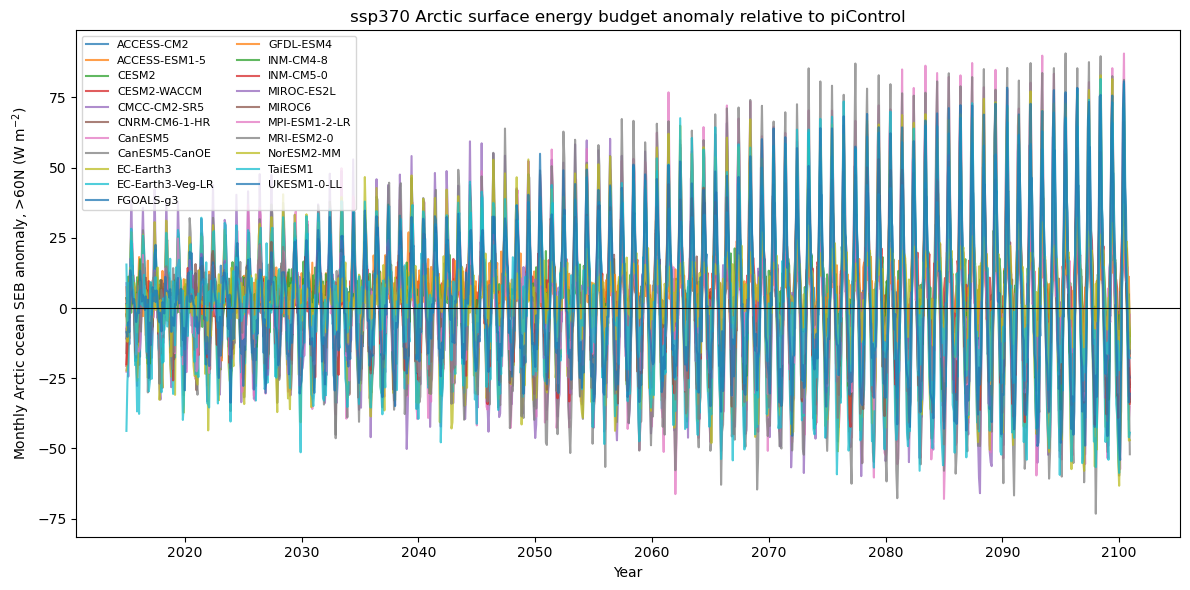

In [22]:
plot_df = combined_monthly_seb_anom.copy()

# Convert pandas Period values like 2030-01 to normal datetimes
plot_df["plot_time"] = plot_df["time"].dt.to_timestamp()

plt.figure(figsize=(12, 6))

for source, sub in plot_df.groupby("source"):
    sub = sub.sort_values("plot_time")

    plt.plot(
        sub["plot_time"],
        sub["seb_anom_Wm2"],
        label=source,
        alpha=0.75,
    )

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Monthly Arctic ocean SEB anomaly, >60N (W m$^{-2}$)")
plt.title(f"{PROJ_EXPERIMENT} Arctic surface energy budget anomaly relative to piControl")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [51]:
# ------------------------------------------------------------
# Plot weighted energy vs minSIA anomalies
# ------------------------------------------------------------

START_YEAR = 2030
END_YEAR = 2039   # inclusive


def skewed_gaussian_month_weights(mu, sigma, skew, kurt=2, x=None):
    """
    Circular Gaussian month weights with damped skew.

    sigma controls the overall width.
    Large sigma -> nearly uniform weights, regardless of skew.
    """
    if x is None:
        x = np.arange(1, 13)

    if sigma <= 0:
        return None

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6
    
    # Gaussian envelope
    g = np.exp(-0.5 * np.abs(d / sigma) ** kurt)

    # Stronger damping: skew vanishes as sigma becomes large
    skew_damping = 1 / (1 + (sigma / 6) ** 2)
    effective_skew = skew #* skew_damping  #remove the skew damping for now. It is not needed for the level of std dev we are get, and just adds complexity

    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s

    if np.any(~np.isfinite(w)) or np.isclose(w.sum(), 0):
        return None

    return w / w.sum()

mu=6.866
sigma=2.260
skew=0.036

month_weights = skewed_gaussian_month_weights(mu, sigma, skew)


month_weights = np.array([
    1/12,  # Jan
    1/12,  # Feb
    1/12,  # Mar
    1/12,  # Apr
    1/12,  # May
    1/12,  # Jun
    1/12,  # Jul
    1/12,  # Aug
    1/12,  # Sep
    1/12,  # Oct
    1/12,  # Nov
    1/12,  # Dec
], dtype=float)



# Optional but recommended: check the weights
assert len(month_weights) == 12, "month_weights must have length 12"

print("Sum of weights:", month_weights.sum())

Sum of weights: 1.0


In [52]:
# ------------------------------------------------------------
# Select the timeslice
# ------------------------------------------------------------

seb_slice = combined_monthly_seb_anom[
    (combined_monthly_seb_anom["year"] >= START_YEAR)
    & (combined_monthly_seb_anom["year"] <= END_YEAR)
].copy()

sia_slice = combined_summer_min_sia_anom[
    (combined_summer_min_sia_anom["year"] >= START_YEAR)
    & (combined_summer_min_sia_anom["year"] <= END_YEAR)
].copy()

print(f"SEB rows in slice: {len(seb_slice)}")
print(f"SIA rows in slice: {len(sia_slice)}")


SEB rows in slice: 2520
SIA rows in slice: 170


In [53]:

# ------------------------------------------------------------
# Average monthly SEB anomalies over the timeslice
#
# For each model:
#   Q_Jan = mean of all January SEB anomalies from 2030-2040
#   Q_Feb = mean of all February SEB anomalies from 2030-2040
#   ...
# ------------------------------------------------------------

model_cols_seb = [
    "institution",
    "source",
    "member",
    "grid",
    "experiment",
]

monthly_q = (
    seb_slice
    .groupby(model_cols_seb + ["month"], as_index=False)
    .agg(
        mean_monthly_seb_anom_Wm2=("seb_anom_Wm2", "mean"),
    )
)

monthly_q.head()

,institution,source,member,grid,experiment,month,mean_monthly_seb_anom_Wm2
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,1,-2.011202
1,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,2,-5.846444
2,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,3,0.264853
3,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,4,0.929081
4,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,5,7.702169


In [54]:
# ------------------------------------------------------------
# Pivot to one row per model, with columns month 1..12
# ------------------------------------------------------------

monthly_q_pivot = (
    monthly_q
    .pivot_table(
        index=model_cols_seb,
        columns="month",
        values="mean_monthly_seb_anom_Wm2",
    )
    .reset_index()
)

# Make sure all months exist as columns, in order 1..12
for m in range(1, 13):
    if m not in monthly_q_pivot.columns:
        monthly_q_pivot[m] = np.nan

monthly_q_pivot = monthly_q_pivot[model_cols_seb + list(range(1, 13))]

monthly_q_pivot.head()

month,institution,source,member,grid,experiment,1,2,3,4,5,6,7,8,9,10,11,12
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,-2.011202,-5.846444,0.264853,0.929081,7.702169,18.708706,22.967150,13.426543,8.679306,-3.403525,-3.495080,-4.342685
1,CAS,FGOALS-g3,r1i1p1f1,gn,ssp370,-2.749337,-7.608344,-0.633867,-0.303169,7.288998,20.601638,20.214045,14.622065,3.801605,-7.105941,-9.890194,-7.567933
2,CCCma,CanESM5,r1i1p1f1,gn,ssp370,-21.126583,-18.116646,-10.550820,-1.632464,16.055263,34.338625,32.872987,18.026014,6.356866,-4.260002,-22.530027,-28.850006
3,CCCma,CanESM5-CanOE,r1i1p2f1,gn,ssp370,-24.834862,-22.226370,-12.377517,0.376233,19.945258,37.550798,36.479249,17.858823,3.329918,-9.241532,-24.185710,-34.331981
4,CMCC,CMCC-CM2-SR5,r1i1p1f1,gn,ssp370,-27.648139,-20.760063,-15.755952,-0.008813,17.998095,42.070448,21.317061,5.494211,1.279573,-3.940627,-14.238444,-28.165737


In [55]:
# ------------------------------------------------------------
# Calculate weighted annual energy anomaly:
#
#   Q*_ann = sum_m w_m * Q_m
#
# where Q_m is the mean anomaly for calendar month m
# over the selected timeslice.
# ------------------------------------------------------------

q_values = monthly_q_pivot[list(range(1, 13))].to_numpy(dtype=float)

monthly_q_pivot["Qstar_ann_Wm2"] = np.nansum(
    q_values * month_weights.reshape(1, 12),
    axis=1,
)

# Optional: require all 12 months to be present.
monthly_q_pivot["n_months_available"] = np.isfinite(q_values).sum(axis=1)

qstar_df = monthly_q_pivot[
    monthly_q_pivot["n_months_available"] == 12
].copy()

qstar_df.head()

month,institution,source,member,grid,experiment,1,2,3,4,5,6,7,8,9,10,11,12,Qstar_ann_Wm2,n_months_available
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,-2.011202,-5.846444,0.264853,0.929081,7.702169,18.708706,22.967150,13.426543,8.679306,-3.403525,-3.495080,-4.342685,4.464906,12
1,CAS,FGOALS-g3,r1i1p1f1,gn,ssp370,-2.749337,-7.608344,-0.633867,-0.303169,7.288998,20.601638,20.214045,14.622065,3.801605,-7.105941,-9.890194,-7.567933,2.555797,12
2,CCCma,CanESM5,r1i1p1f1,gn,ssp370,-21.126583,-18.116646,-10.550820,-1.632464,16.055263,34.338625,32.872987,18.026014,6.356866,-4.260002,-22.530027,-28.850006,0.048600,12
3,CCCma,CanESM5-CanOE,r1i1p2f1,gn,ssp370,-24.834862,-22.226370,-12.377517,0.376233,19.945258,37.550798,36.479249,17.858823,3.329918,-9.241532,-24.185710,-34.331981,-0.971474,12
4,CMCC,CMCC-CM2-SR5,r1i1p1f1,gn,ssp370,-27.648139,-20.760063,-15.755952,-0.008813,17.998095,42.070448,21.317061,5.494211,1.279573,-3.940627,-14.238444,-28.165737,-1.863199,12


In [56]:
# ------------------------------------------------------------
# Average summer-minimum SIA anomaly over the same timeslice
# ------------------------------------------------------------

model_cols_sia = [
    "institution",
    "source",
    "member",
    "siconc_grid",
    "experiment",
]

mean_sia = (
    sia_slice
    .groupby(model_cols_sia, as_index=False)
    .agg(
        mean_summer_min_sia_anom_Mkm2=("summer_min_sia_anom_Mkm2", "mean"),
        mean_summer_min_sia_Mkm2=("summer_min_sia_Mkm2", "mean"),
        mean_summer_min_month=("summer_min_month", "mean"),
        n_years=("year", "nunique"),
    )
)

mean_sia.head()

,institution,source,member,siconc_grid,experiment,mean_summer_min_sia_anom_Mkm2,mean_summer_min_sia_Mkm2,mean_summer_min_month,n_years
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp370,-4.566333,1.526989,9.0,10
1,CAS,FGOALS-g3,r1i1p1f1,gn,ssp370,-0.155865,0.556259,8.9,10
2,CCCma,CanESM5,r1i1p1f1,gn,ssp370,-5.323654,1.352065,9.0,10
3,CCCma,CanESM5-CanOE,r1i1p2f1,gn,ssp370,-5.952202,1.096191,9.0,10
4,CNRM-CERFACS,CNRM-CM6-1-HR,r1i1p1f2,gn,ssp370,-2.852484,3.275544,9.0,10


In [57]:
# ------------------------------------------------------------
# Merge weighted energy and SIA anomaly
#
# Merge on institution/source/member/experiment.
# The atmosphere grid and sea-ice grid are usually different,
# so do not merge on grid.
# ------------------------------------------------------------

scatter_df = qstar_df.merge(
    mean_sia,
    on=["institution", "source", "member", "experiment"],
    how="inner",
)

scatter_df = scatter_df.dropna(
    subset=[
        "Qstar_ann_Wm2",
        "mean_summer_min_sia_anom_Mkm2",
    ]
).copy()

print(f"Models in scatter: {len(scatter_df)}")

display(
    scatter_df[
        [
            "source",
            "member",
            "grid",
            "siconc_grid",
            "Qstar_ann_Wm2",
            "mean_summer_min_sia_anom_Mkm2",
            "n_years",
        ]
    ].sort_values("source")
)

Models in scatter: 17


,source,member,grid,siconc_grid,Qstar_ann_Wm2,mean_summer_min_sia_anom_Mkm2,n_years
6,ACCESS-CM2,r1i1p1f1,gn,gn,2.585863,-4.064610,10
5,ACCESS-ESM1-5,r1i1p1f1,gn,gn,4.753406,-2.809422,10
4,CNRM-CM6-1-HR,r1i1p1f2,gr,gn,0.471259,-2.852484,10
2,CanESM5,r1i1p1f1,gn,gn,0.048600,-5.323654,10
3,CanESM5-CanOE,r1i1p2f1,gn,gn,-0.971474,-5.952202,10
7,EC-Earth3,r1i1p1f1,gr,gn,-2.007319,-5.237991,10
8,EC-Earth3-Veg-LR,r1i1p1f1,gr,gn,-3.841016,-4.693426,10
1,FGOALS-g3,r1i1p1f1,gn,gn,2.555797,-0.155865,10
16,GFDL-ESM4,r1i1p1f1,gr1,gn,2.949582,-1.316924,10
9,INM-CM4-8,r1i1p1f1,gr1,gr1,3.310775,-1.252237,10


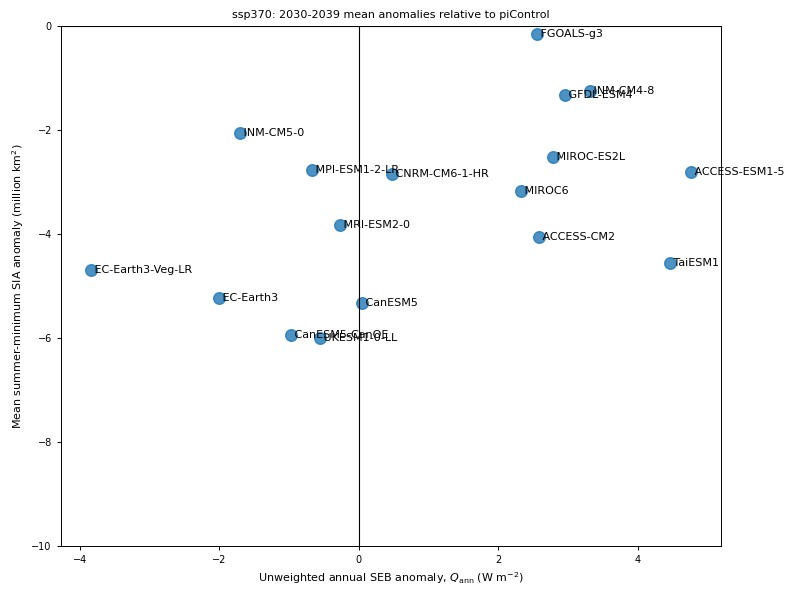

In [58]:
# ------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    scatter_df["Qstar_ann_Wm2"],
    scatter_df["mean_summer_min_sia_anom_Mkm2"],
    s=70,
    alpha=0.8,
)

for _, row in scatter_df.iterrows():
    plt.text(
        row["Qstar_ann_Wm2"],
        row["mean_summer_min_sia_anom_Mkm2"],
        " " + row["source"],
        fontsize=8,
        va="center",
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

if np.allclose(month_weights, 1/12):
    plt.xlabel(r"Unweighted annual SEB anomaly, $Q_{\mathrm{ann}}$ (W m$^{-2}$)")
else:
    plt.xlabel(r"Weighted annual SEB anomaly, $Q^*_{\mathrm{ann}}$ (W m$^{-2}$)")
    

plt.ylabel("Mean summer-minimum SIA anomaly (million km$^2$)")
plt.title(f"{PROJ_EXPERIMENT}: {START_YEAR}-{END_YEAR} mean anomalies relative to piControl")
plt.ylim(-10,0)
plt.tight_layout()
plt.show()

Models available before exclusion: 17
Models excluded: ['FGOALS-g3']
Models retained: 16


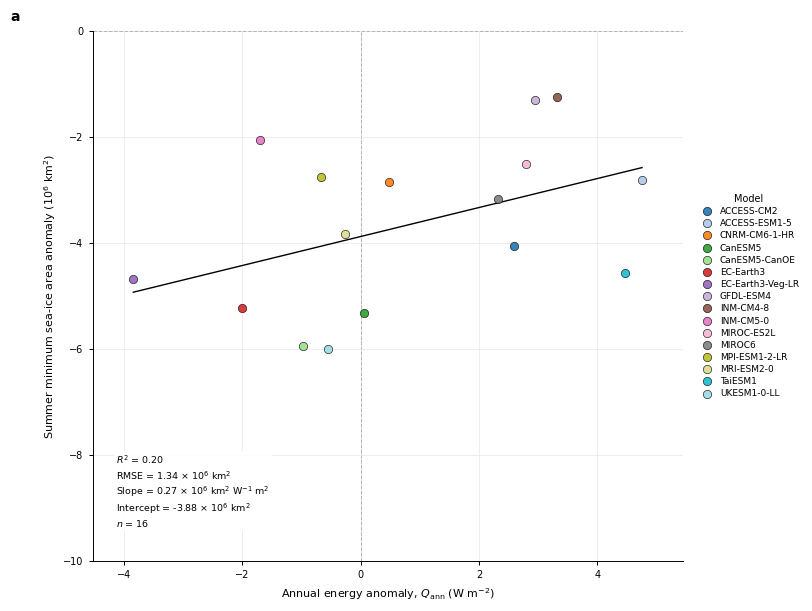

In [ ]:

from matplotlib.lines import Line2D

SAVE_FIG = False

# Optional output folder
FIGDIR = Path("Figures")
FIGDIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Models to exclude from plot and fit as outliers
# ------------------------------------------------------------

excluded_models = [
    "FGOALS-g3",
]

# ------------------------------------------------------------
# Figure settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

x_col = "Qstar_ann_Wm2"
y_col = "mean_summer_min_sia_anom_Mkm2"

plot_df_all = scatter_df.dropna(subset=[x_col, y_col]).copy()

plot_df = plot_df_all[
    ~plot_df_all["source"].isin(excluded_models)
].copy()

excluded_in_plot = sorted(
    set(plot_df_all["source"]).intersection(excluded_models)
)

print(f"Models available before exclusion: {plot_df_all['source'].nunique()}")
print(f"Models excluded: {excluded_in_plot}")
print(f"Models retained: {plot_df['source'].nunique()}")
plot_df = plot_df.sort_values("source")

sources = plot_df["source"].unique()
n_models = len(sources)

# Colourblind-friendly categorical palette.
# tab20 is acceptable for many-model diagnostic / ensemble plots.
cmap = plt.colormaps["tab20"].resampled(max(n_models, 1))
source_colours = {
    source: cmap(i)
    for i, source in enumerate(sources)
}

# ------------------------------------------------------------
# Scatter points
# ------------------------------------------------------------

for source, sub in plot_df.groupby("source", sort=True):
    ax.scatter(
        sub[x_col],
        sub[y_col],
        s=36,
        color=source_colours[source],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.9,
        label=source,
        zorder=3,
    )

# ------------------------------------------------------------
# Linear fit, R², RMSE, slope and intercept
# ------------------------------------------------------------

x = plot_df[x_col].to_numpy(dtype=float)
y = plot_df[y_col].to_numpy(dtype=float)

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

fit_stats = {}

if len(x) >= 3 and not np.allclose(x, x[0]):
    slope, intercept = np.polyfit(x, y, 1)

    xfit = np.linspace(x.min(), x.max(), 200)
    yfit = slope * xfit + intercept

    y_pred = slope * x + intercept

    residuals = y - y_pred
    rmse = np.sqrt(np.mean(residuals**2))

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    fit_stats = {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "rmse": rmse,
        "n": len(x),
    }

    ax.plot(
        xfit,
        yfit,
        color="black",
        linewidth=1.0,
        linestyle="-",
        zorder=2,
    )

    # compact stats annotation.
    # Units:
    #   slope: 10^6 km^2 per W m^-2
    #   intercept and RMSE: 10^6 km^2
    stats_text = (
        rf"$R^2$ = {r2:.2f}" "\n"
        rf"RMSE = {rmse:.2f} $\times$ 10$^6$ km$^2$" "\n"
        rf"Slope = {slope:.2f} $\times$ 10$^6$ km$^2$ W$^{{-1}}$ m$^2$" "\n"
        rf"Intercept = {intercept:.2f} $\times$ 10$^6$ km$^2$" "\n"
        rf"$n$ = {len(x)}"
    )

    ax.text(
        0.04,
        0.06,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=6.8,
        linespacing=1.25,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=5,
    )

# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

ax.axhline(0, color="0.25", linewidth=0.7, linestyle="--", zorder=1)
ax.axvline(0, color="0.25", linewidth=0.7, linestyle="--", zorder=1)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

if np.allclose(month_weights, 1 / 12):
    xlabel = r"Annual energy anomaly, $Q_{\mathrm{ann}}$ (W m$^{-2}$)"
    panel_label = 'a'
else:
    xlabel = r"Weighted annual energy anomaly, $Q^*_{\mathrm{ann}}$ (W m$^{-2}$)"
    panel_label = 'b'

ax.set_xlabel(xlabel)
ax.set_ylabel(r"Summer minimum sea-ice area anomaly (10$^6$ km$^2$)")


# ------------------------------------------------------------
# Limits with padding
# ------------------------------------------------------------

xpad = 0.08 * (plot_df[x_col].max() - plot_df[x_col].min())
ypad = 0.08 * (plot_df[y_col].max() - plot_df[y_col].min())

if np.isfinite(xpad) and xpad > 0:
    ax.set_xlim(plot_df[x_col].min() - xpad, plot_df[x_col].max() + xpad)


# ax.set_ylim(plot_df[y_col].min() - ypad, plot_df[y_col].max() + ypad)
ax.set_ylim(-10, 0)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

ax.grid(
    True,
    which="major",
    color="0.9",
    linewidth=0.5,
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel label
ax.text(
    -0.14,
    1.04,
    panel_label,
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
    ha="left",
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    title="Model",
    title_fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    handletextpad=0.4,
    borderaxespad=0.0,
    labelspacing=0.35,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out_pdf = FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_vs_SIA.pdf"
out_png = FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_vs_SIA.png"

if SAVE_FIG:
    fig.savefig(out_pdf, bbox_inches="tight")
    fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

if SAVE_FIG:
    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")